In [1]:
import pandas as pd

df = pd.read_csv('/Users/zubair/Documents/GitHub/Credit risk model 2.0/cs-training.csv', encoding='latin1', index_col=0)
df.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [2]:
print(df.shape)
df.info()

(150000, 11)
<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 1 to 150000
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      150000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 2   age                                   150000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 4   DebtRatio                             150000 non-null  float64
 5   MonthlyIncome                         120269 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 7   NumberOfTimes90DaysLate               150000 non-null  int64  
 8   NumberRealEstateLoansOrLines          150000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 10  NumberOfDependents                    146076 non-null  float64
dty

In [3]:
df['SeriousDlqin2yrs'].value_counts(normalize=True)

SeriousDlqin2yrs
0    0.93316
1    0.06684
Name: proportion, dtype: float64

In [4]:
df.describe()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


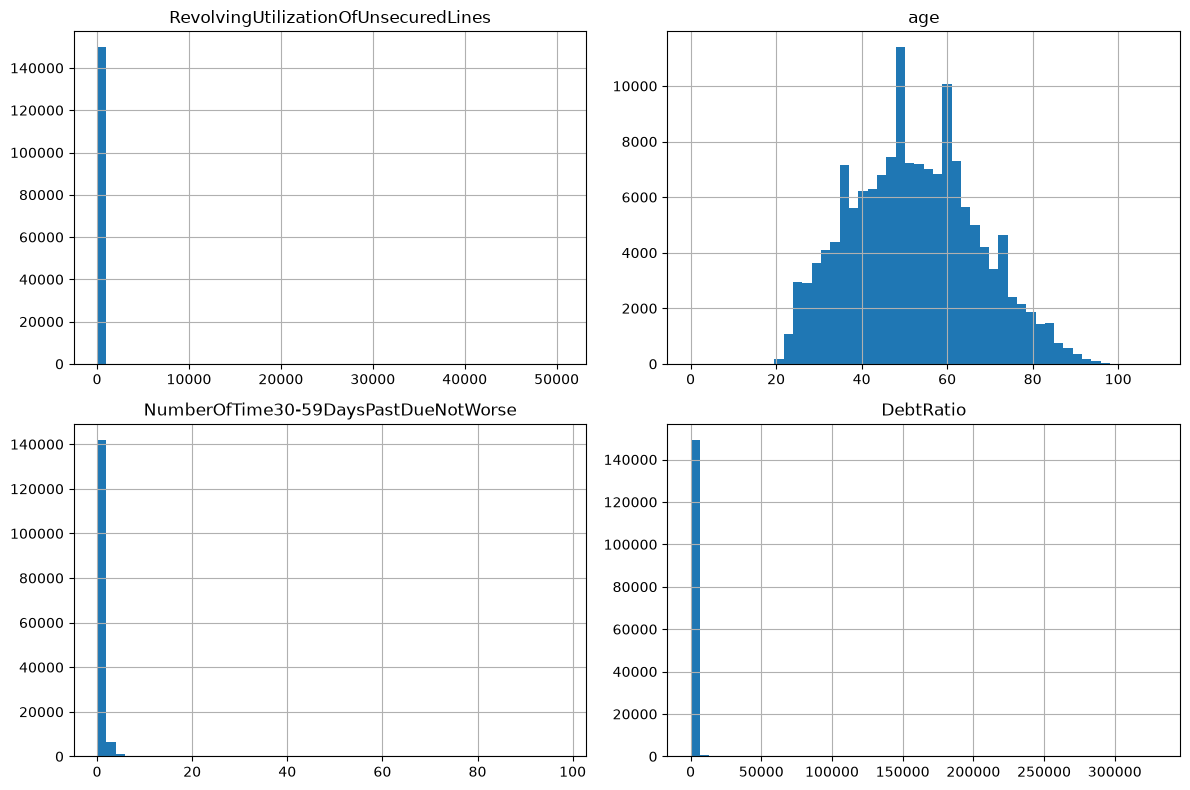

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

df['RevolvingUtilizationOfUnsecuredLines'].hist(bins=50, ax=axes[0,0])
axes[0,0].set_title('RevolvingUtilizationOfUnsecuredLines')

df['age'].hist(bins=50, ax=axes[0,1])
axes[0,1].set_title('age')

df['NumberOfTime30-59DaysPastDueNotWorse'].hist(bins=50, ax=axes[1,0])
axes[1,0].set_title('NumberOfTime30-59DaysPastDueNotWorse')

df['DebtRatio'].hist(bins=50, ax=axes[1,1])
axes[1,1].set_title('DebtRatio')

plt.tight_layout()
plt.show()

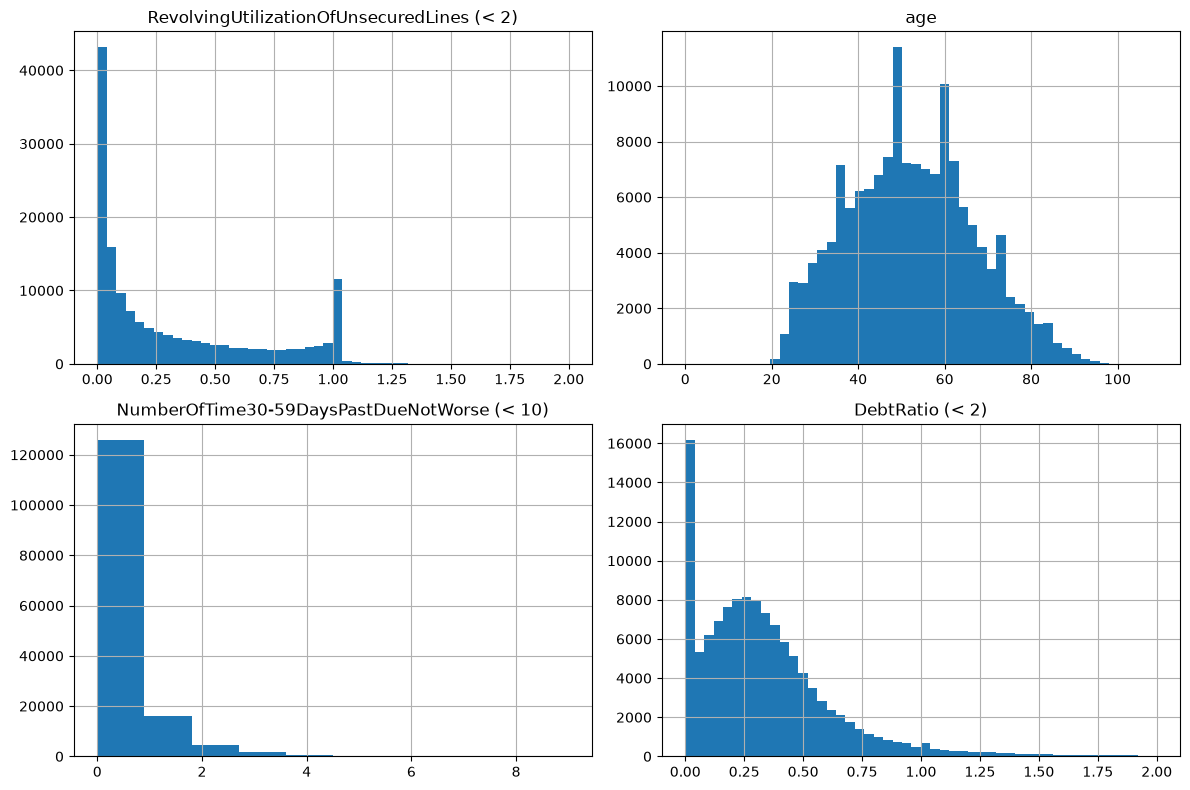

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

df[df['RevolvingUtilizationOfUnsecuredLines'] < 2]['RevolvingUtilizationOfUnsecuredLines'].hist(bins=50, ax=axes[0,0])
axes[0,0].set_title('RevolvingUtilizationOfUnsecuredLines (< 2)')

df['age'].hist(bins=50, ax=axes[0,1])
axes[0,1].set_title('age')

df[df['NumberOfTime30-59DaysPastDueNotWorse'] < 10]['NumberOfTime30-59DaysPastDueNotWorse'].hist(bins=10, ax=axes[1,0])
axes[1,0].set_title('NumberOfTime30-59DaysPastDueNotWorse (< 10)')

df[df['DebtRatio'] < 2]['DebtRatio'].hist(bins=50, ax=axes[1,1])
axes[1,1].set_title('DebtRatio (< 2)')

plt.tight_layout()
plt.show()

In [7]:
print("Age = 0 rows:", (df['age'] == 0).sum())
print("Past-due 96/98 rows:", ((df['NumberOfTime30-59DaysPastDueNotWorse'] >= 96) | 
                                 (df['NumberOfTimes90DaysLate'] >= 96) | 
                                 (df['NumberOfTime60-89DaysPastDueNotWorse'] >= 96)).sum())
print("RevolvingUtilization > 2:", (df['RevolvingUtilizationOfUnsecuredLines'] > 2).sum())
print("DebtRatio > 2:", (df['DebtRatio'] > 2).sum())

Age = 0 rows: 1
Past-due 96/98 rows: 269
RevolvingUtilization > 2: 371
DebtRatio > 2: 31045


In [8]:
df[df['DebtRatio'] > 2][['DebtRatio', 'MonthlyIncome']].describe()

,DebtRatio,MonthlyIncome
count,31045.000000,3301.000000
mean,1704.315902,815.863375
std,4214.550941,2090.107580
min,2.000400,0.000000
25%,181.000000,0.000000
50%,1197.000000,1.000000
75%,2395.000000,770.000000
max,329664.000000,33333.000000


In [9]:
print("Rows with DebtRatio > 2 AND MonthlyIncome missing:", 
      df[(df['DebtRatio'] > 2) & (df['MonthlyIncome'].isna())].shape[0])

Rows with DebtRatio > 2 AND MonthlyIncome missing: 27744


In [10]:
# Dropping the single age=0 anomaly from set
df = df[df['age'] > 0].copy()

# Flagging and imputing missing MonthlyIncome
df['MonthlyIncome_missing'] = df['MonthlyIncome'].isna().astype(int)
median_income = df['MonthlyIncome'].median()
df['MonthlyIncome'] = df['MonthlyIncome'].fillna(median_income)

print("Age=0 rows remaining:", (df['age'] == 0).sum())
print("MonthlyIncome missing after imputation:", df['MonthlyIncome'].isna().sum())
print("Median income used:", median_income)

Age=0 rows remaining: 0
MonthlyIncome missing after imputation: 0
Median income used: 5400.0


In [11]:
# Capping DebtRatio, flagging rows that were capped
df['DebtRatio_capped'] = (df['DebtRatio'] > 2).astype(int)
df['DebtRatio'] = df['DebtRatio'].clip(upper=2)

# Sentinel past-due values
sentinel_cols = ['NumberOfTime30-59DaysPastDueNotWorse', 
                  'NumberOfTimes90DaysLate', 
                  'NumberOfTime60-89DaysPastDueNotWorse']

df['HasSentinelPastDue'] = (df[sentinel_cols] >= 96).any(axis=1).astype(int)
for col in sentinel_cols:
    df[col] = df[col].clip(upper=18)

# RevolvingUtilization cap
df['RevolvingUtilization_capped'] = (df['RevolvingUtilizationOfUnsecuredLines'] > 2).astype(int)
df['RevolvingUtilizationOfUnsecuredLines'] = df['RevolvingUtilizationOfUnsecuredLines'].clip(upper=2)

print("DebtRatio > 2 after capping:", (df['DebtRatio'] > 2).sum())
print("Sentinel flag count:", df['HasSentinelPastDue'].sum())
print("RevolvingUtilization capped count:", df['RevolvingUtilization_capped'].sum())

DebtRatio > 2 after capping: 0
Sentinel flag count: 269
RevolvingUtilization capped count: 371


In [12]:
df['NumberOfDependents_missing'] = df['NumberOfDependents'].isna().astype(int)
df['NumberOfDependents'] = df['NumberOfDependents'].fillna(0)

print("NumberOfDependents missing after imputation:", df['NumberOfDependents'].isna().sum())

NumberOfDependents missing after imputation: 0
